In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, math, warnings
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

from ridge_regression_utils import (
    load_cell_data, build_ridge_matrices,
    run_ridge_regression, apply_fdr, plot_ridge_results,
    WAVEFORM_LABELS,
)

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated',
                        category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', message=r'invalid value encountered in log10',
                        category=RuntimeWarning, module=r'.*specparam.*')

In [2]:
# ── Cell configuration ────────────────────────────────────────────────────────
cell_num = 15

# Symmetric 50 ms windows immediately around the spike
PRE_WIN      = (-0.055, -0.005)  # pre-spike:  −55 → −5 ms
POST_WIN     = ( 0.005,  0.055)  # post-spike: +5 → +55 ms
BASELINE_WIN = (-0.20,  -0.10)   # baseline: −200 → −100 ms

# Ridge regression settings
ALPHAS          = np.logspace(-3, 3, 100)
N_PERM          = 1000
RNG_SEED        = 42
FORCE_RECOMPUTE = False   # set True to ignore cached pickle and rerun

In [3]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
df_reg, specparam_by_spike, lfp_windows_by_spike = load_cell_data(cell_num)

Found 16 chunk files. Assembling master list...
Loading Chunks: 100%|██████████| 16/16 [00:03<00:00,  5.33it/s]
Success! Master list assembled with 3180 total spikes.
c15: 3180 spikes loaded


In [4]:
# ── 2. Build matrices ─────────────────────────────────────────────────────────
(X_waveform, X_log_isi, X_both, waveform_labels,
 Y, target_names, target_labels) = build_ridge_matrices(
    df_reg, specparam_by_spike, lfp_windows_by_spike,
    pre_win=PRE_WIN, post_win=POST_WIN, baseline_win=BASELINE_WIN,
)

predictor_sets = {
    'Waveform only':      (X_waveform, waveform_labels),
    'Log ISI only':       (X_log_isi,  ['Log ISI']),
    'Waveform + Log ISI': (X_both,     waveform_labels + ['Log ISI']),
}

Target NaN %:
  Pre LFP Amp             0.0%
  Pre LFP Std             0.0%
  Pre Gamma AUC           0.0%
  Pre Exponent            0.0%
  Pre Theta AUC           0.0%
  Pre−BL LFP Amp          0.0%
  Pre−BL LFP Std          0.0%
  Pre−BL Gamma AUC        0.0%
  Pre−BL Exponent         0.0%
  Pre−BL Theta AUC        0.0%
  Δ LFP Amp               0.0%
  Δ LFP Std               0.0%
  Δ Gamma AUC             0.0%
  Δ Exponent              0.0%
  Δ Theta AUC             0.0%


In [5]:
# ── 3. Ridge regression (5-fold CV + permutation test) ────────────────────────
import os, sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT

save_path = os.path.join(SPE1_PICKLE_ROOT, 'ridge_regression_pickles', f'c{cell_num}_ridge_results.pkl')

results = run_ridge_regression(
    Y, predictor_sets, target_names,
    n_perm=N_PERM, rng_seed=RNG_SEED, alphas=ALPHAS,
    save_path=save_path, force_recompute=FORCE_RECOMPUTE,
)

ridge CV: 100%|██████████| 45/45 [10:11<00:00, 13.60s/model, pred=Waveform +, target=delta_theta_]

  Saved: c15_ridge_results.pkl


In [6]:
# ── 4. FDR correction + save final results ────────────────────────────────────
import pickle

results = apply_fdr(results, target_names, predictor_sets)

# Overwrite pickle with FDR-corrected results so the full final state is cached
with open(save_path, 'wb') as f:
    pickle.dump(results, f)
print(f'Saved final results (with FDR): {os.path.basename(save_path)}')

FDR (BH, q=0.05): 29/45 raw p<0.05 → 28/45 after correction

Target                         Waveform only          Log ISI only    Waveform + Log ISI
----------------------------------------------------------------------------------------
pre_lfp_amp                    +0.0150* α=81      -0.0038  α=1e+03    +0.0148* α=1.1e+02
pre_lfp_std                    +0.0332* α=35         +0.0568* α=13         +0.0883* α=17
pre_gamma_auc               +0.0042* α=1e+03      -0.0004  α=1e+03      +0.0041* α=1e+03
pre_exponent                   +0.0081* α=31      -0.0034  α=1e+03         +0.0069* α=31
pre_theta_auc             +0.0117* α=3.3e+02    +0.0013* α=2.8e+02    +0.0147* α=2.8e+02
prebc_lfp_amp             +0.0145* α=2.8e+02        +0.1074* α=8.7         +0.1186* α=93
prebc_lfp_std               -0.0028  α=1e+03    -0.0009  α=3.3e+02      -0.0014  α=1e+03
prebc_gamma_auc             -0.0028  α=1e+03    +0.0027* α=2.8e+02      +0.0001~ α=1e+03
prebc_exponent              -0.0015  α=1e+03    +

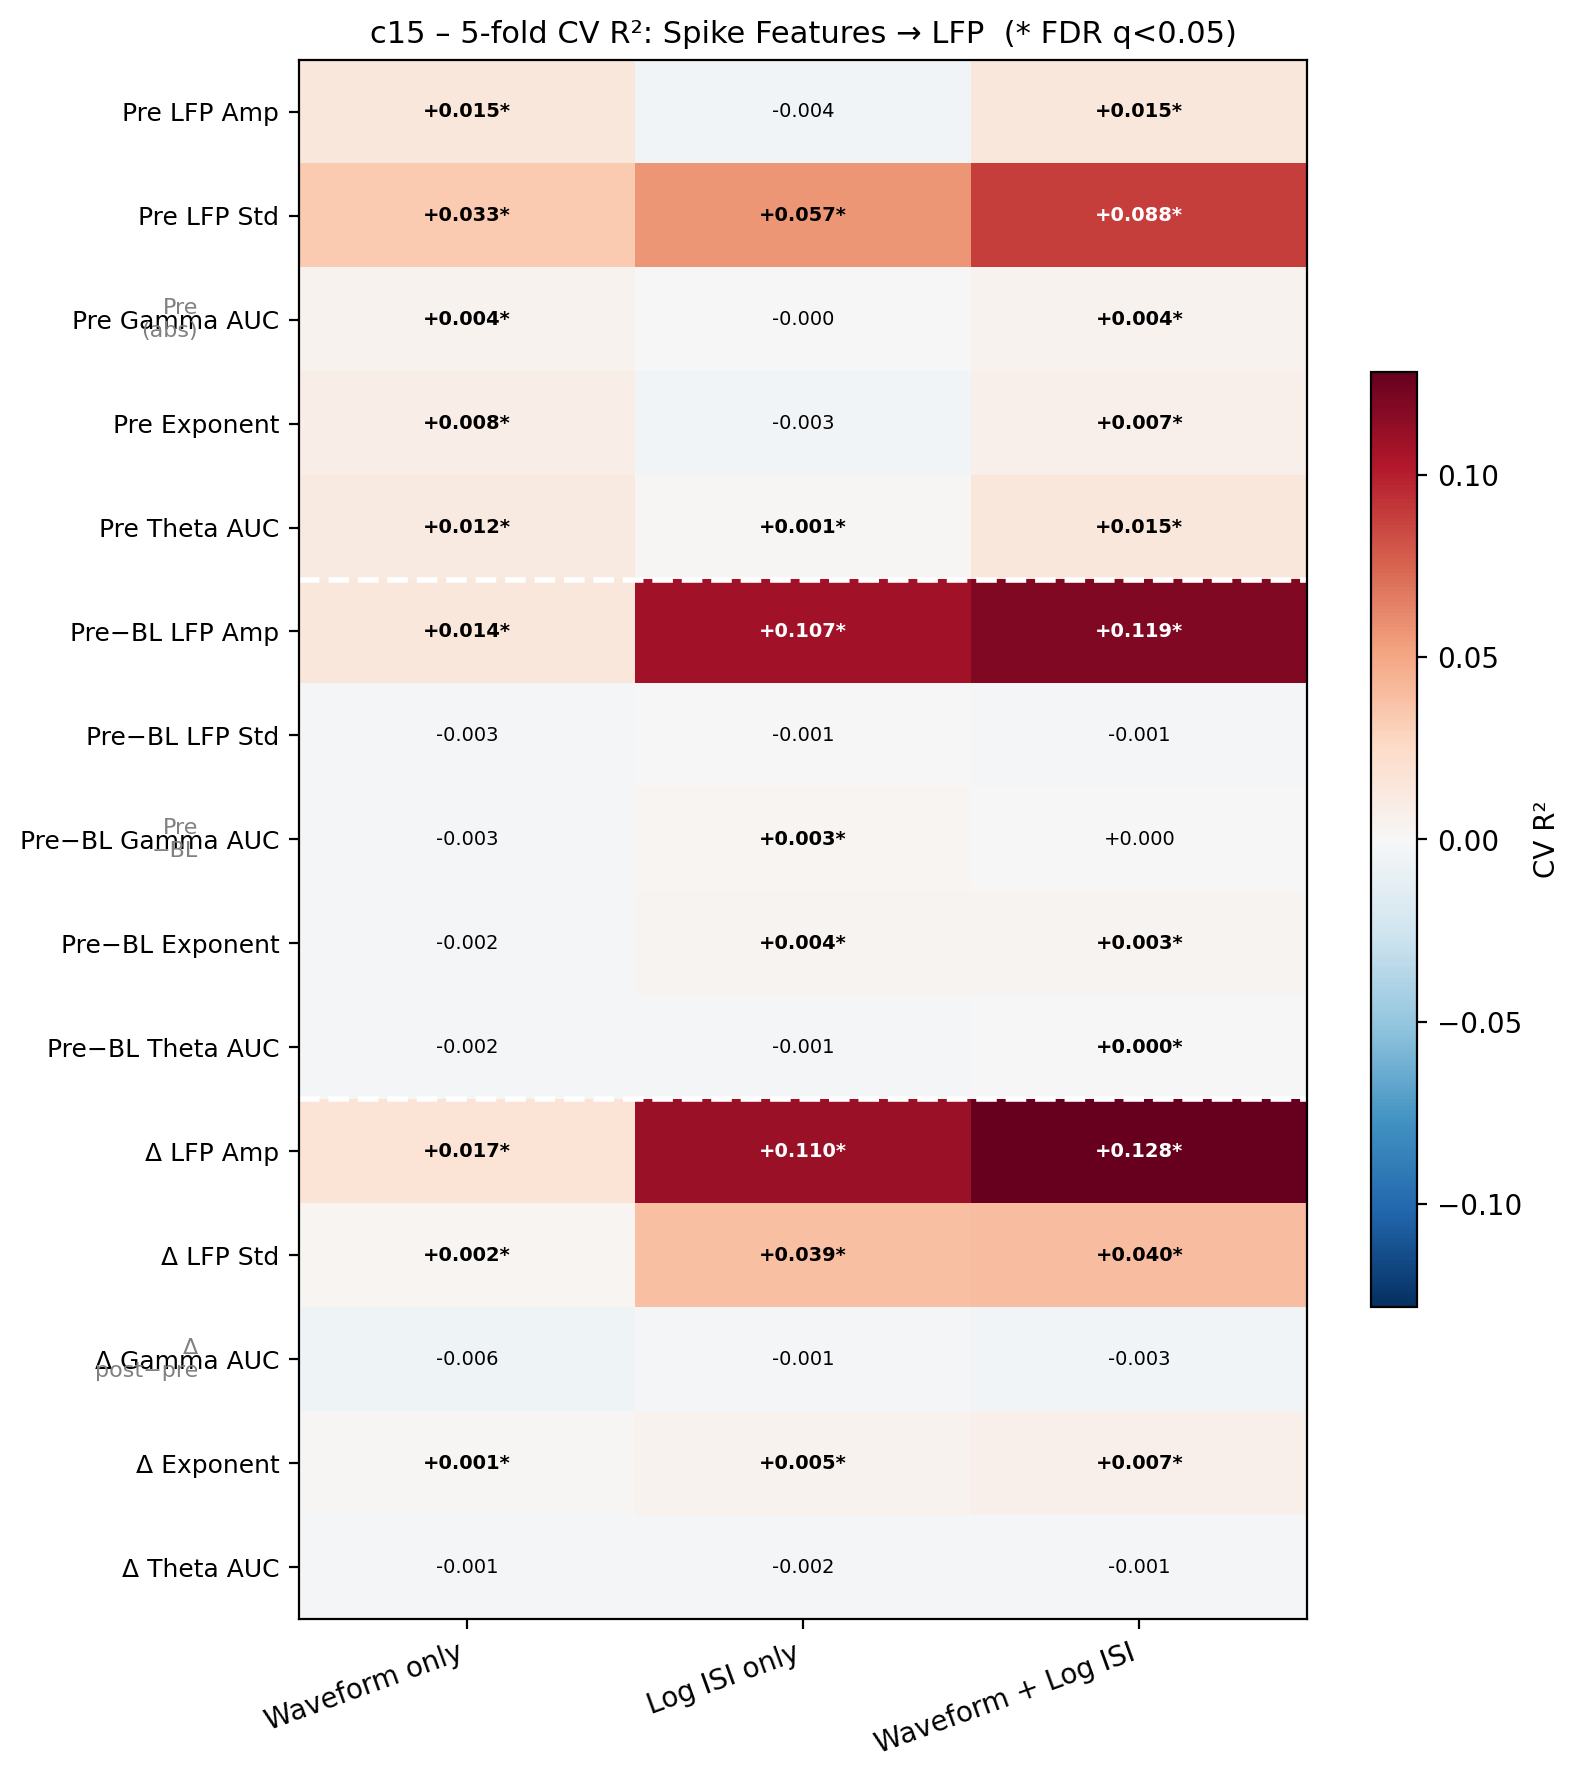

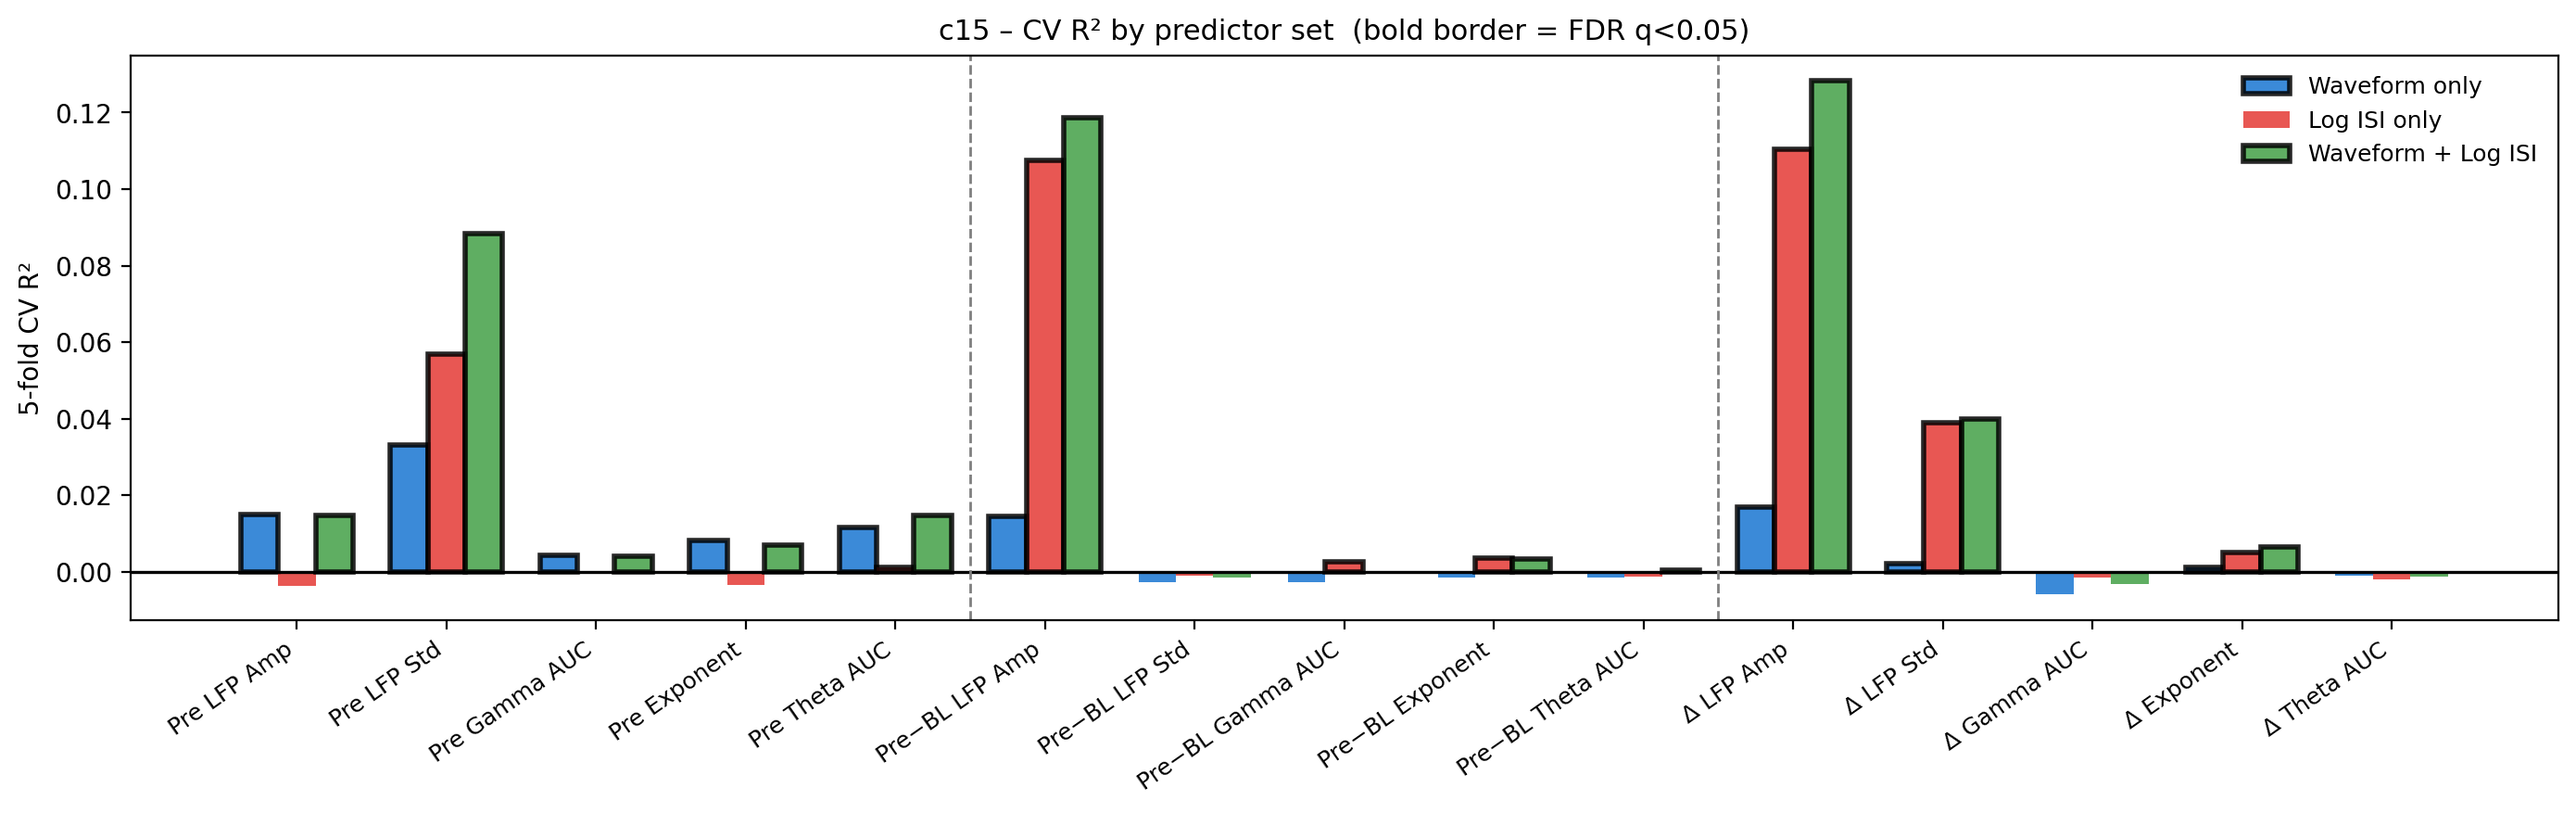

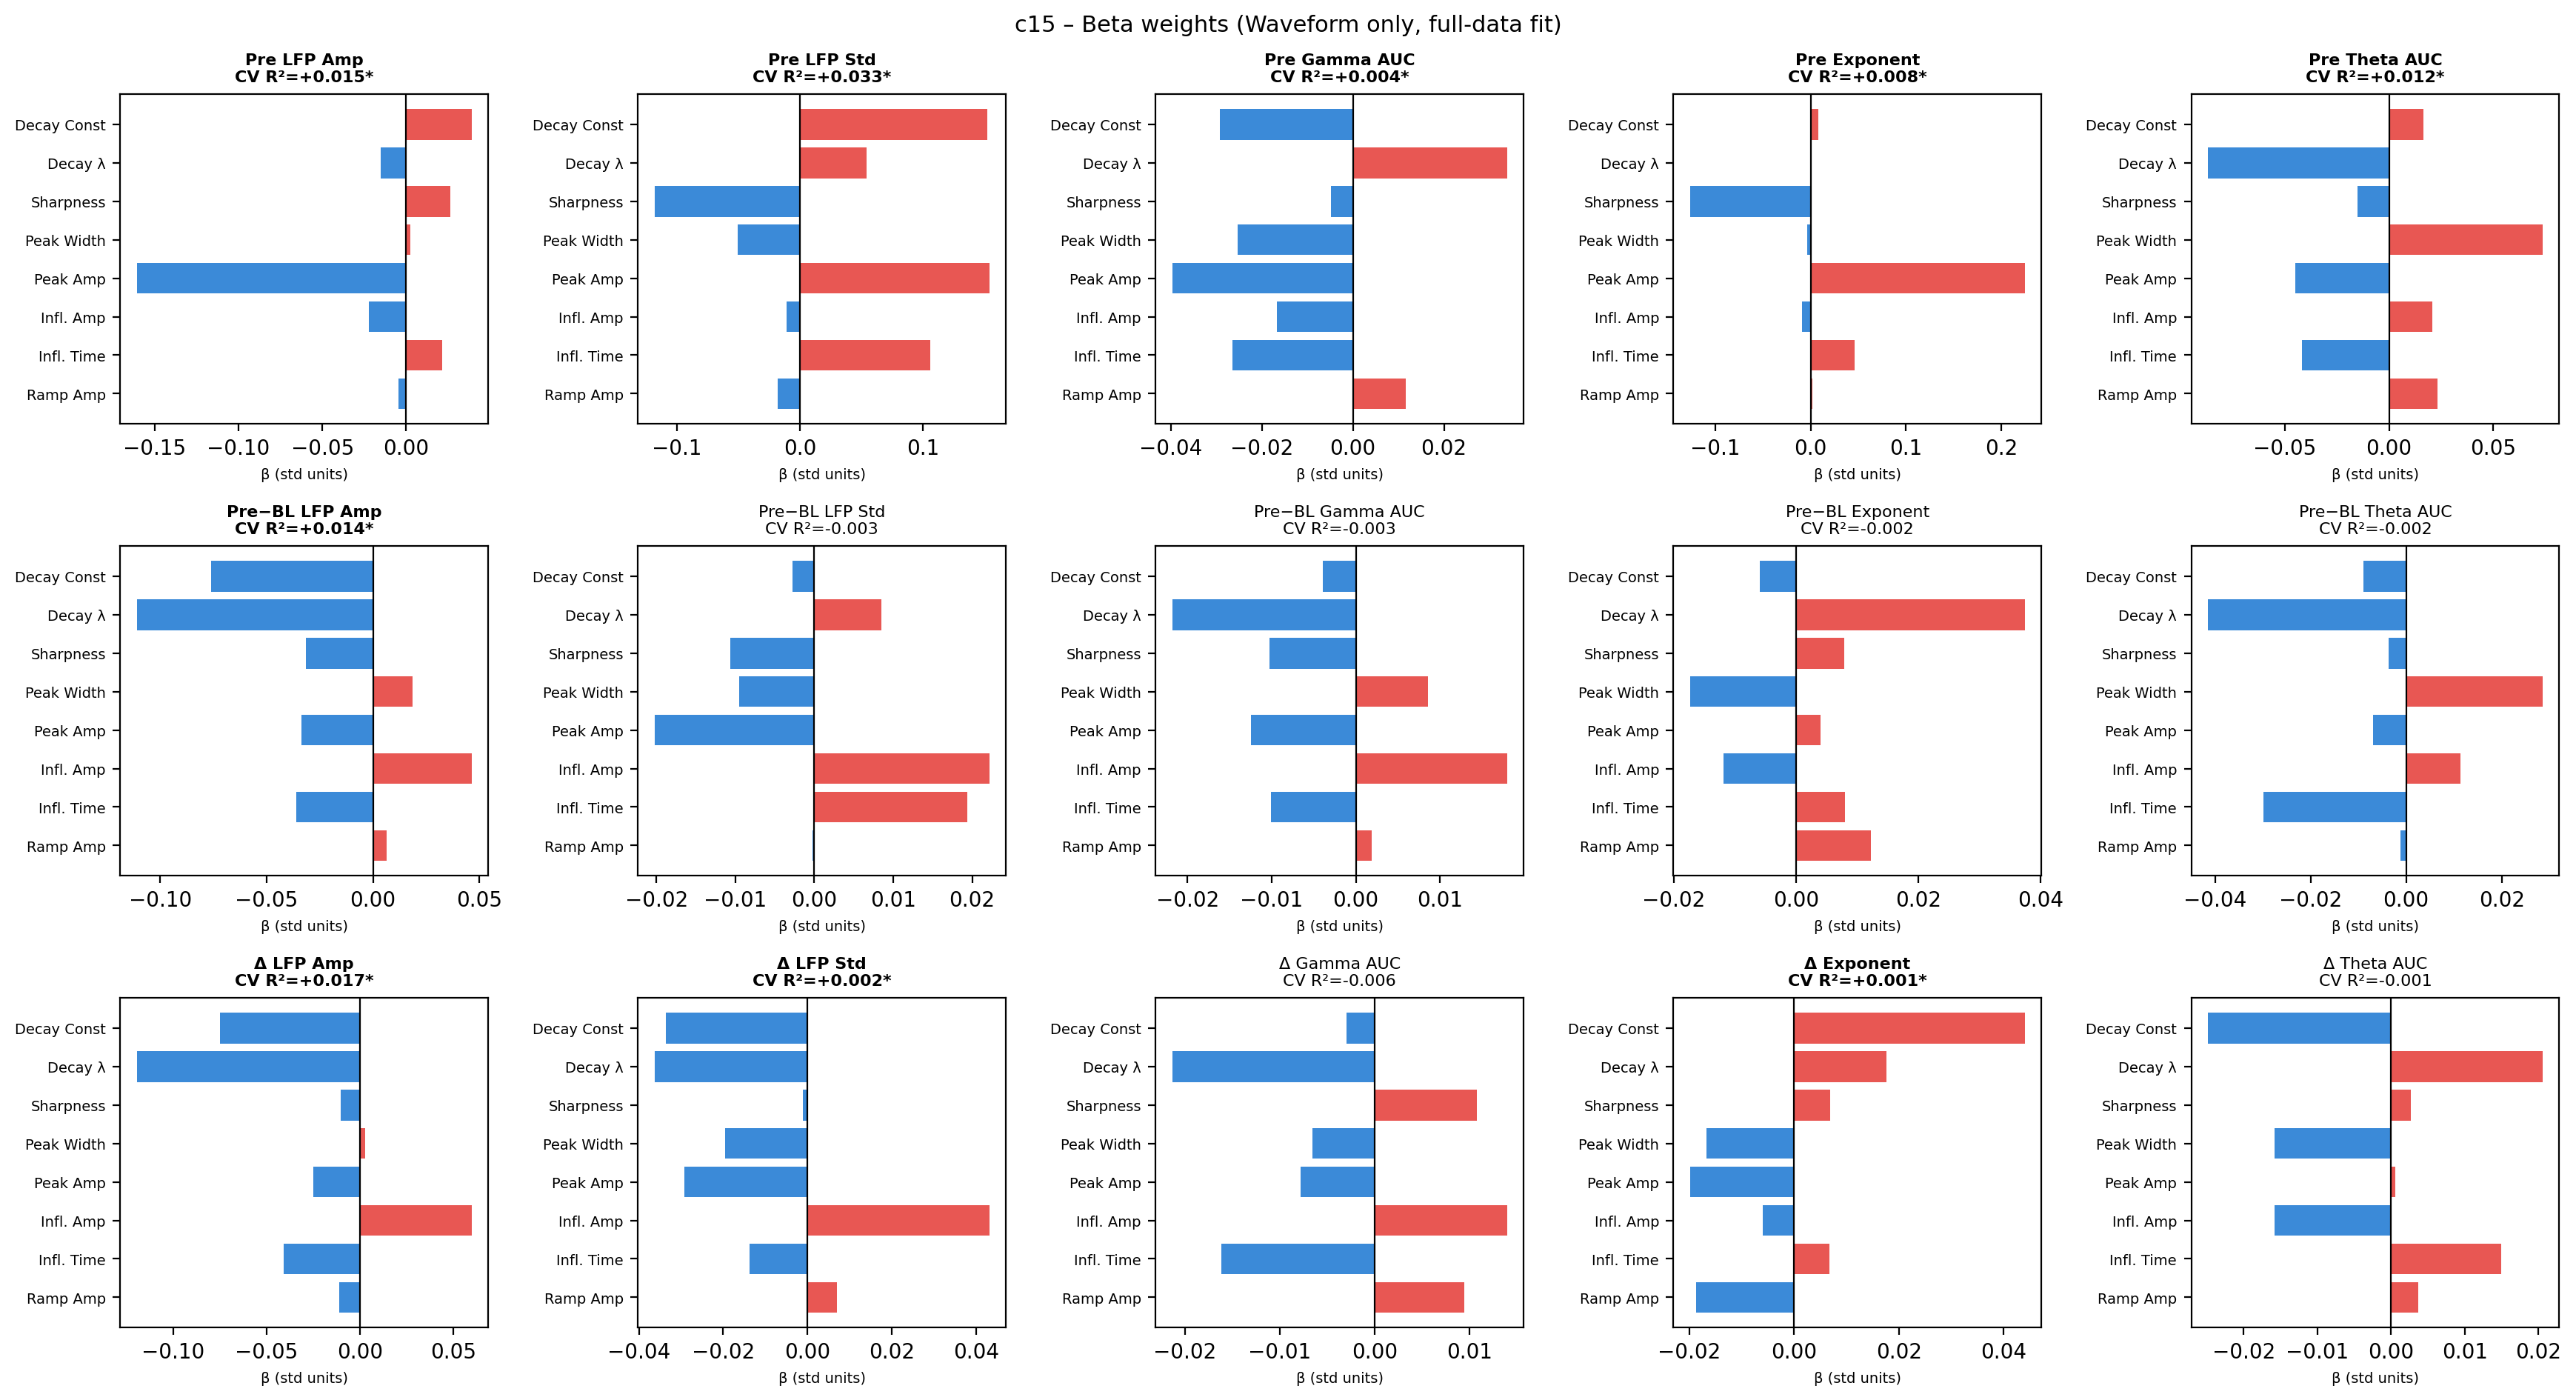

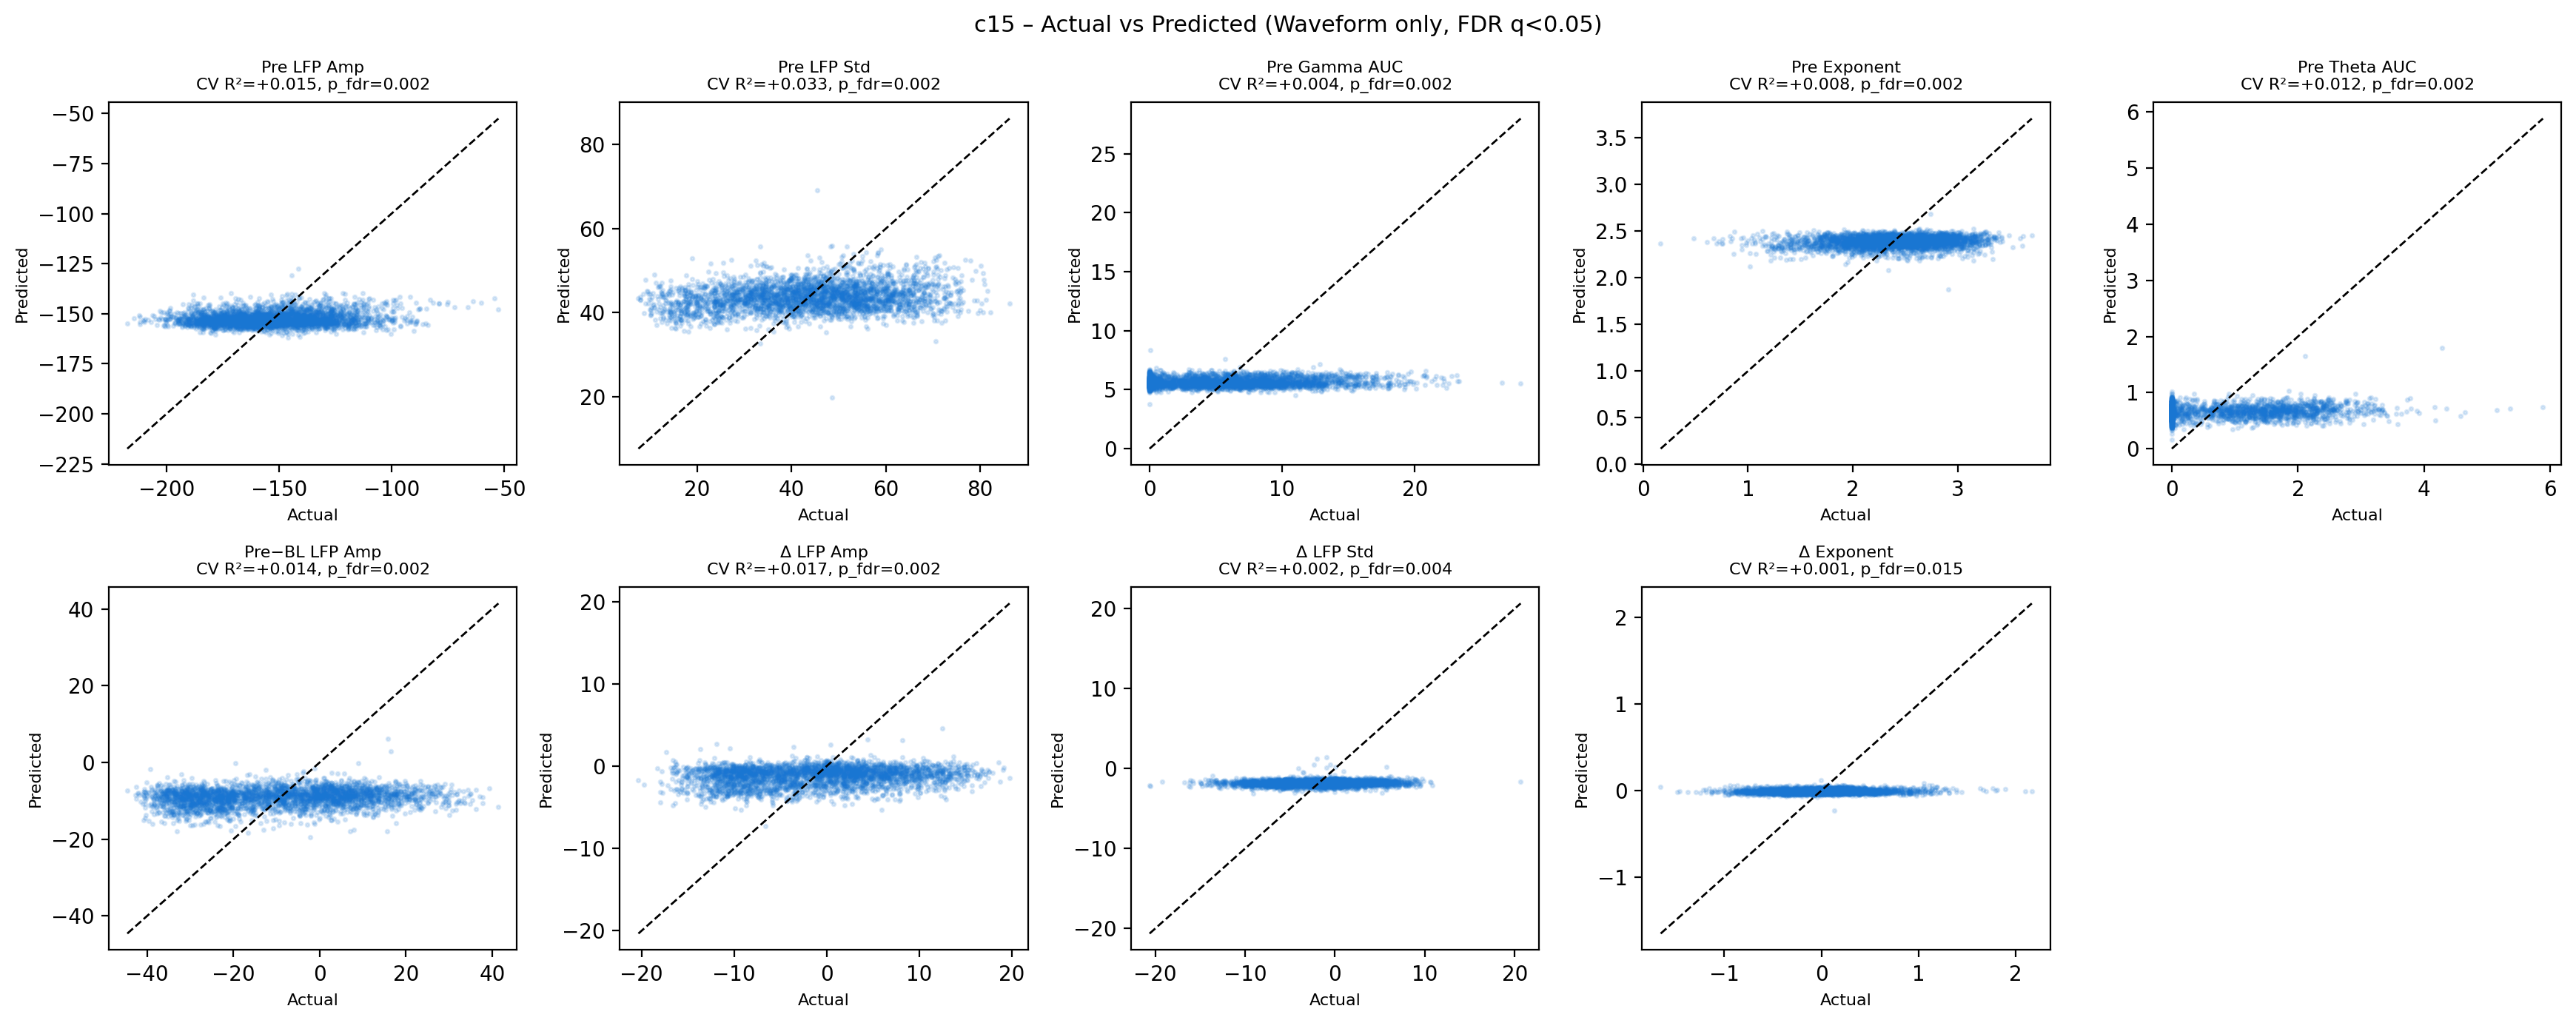

In [7]:
# ── 5. Plots ──────────────────────────────────────────────────────────────────
plot_ridge_results(
    cell_num, results, target_names, target_labels,
    predictor_sets, waveform_labels, Y, X_waveform,
)